<a href="https://colab.research.google.com/github/GODRATAN/FlyRank_ML-Intern/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GODRATAN/FlyRank_ML_Assignment/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Content Refresh Prioritization from Search Performance Signals

## Research question

Can a simple machine-learning model help rank content observations for human review when the goal is to identify observations with a higher measured risk of future search-performance decline?

## Decision supported

The analysis supports a content-editor decision: **which content observations should be reviewed first**.

The model is used as a decision-support ranking tool. A higher score indicates a higher measured probability of the future-decline outcome defined for this experiment; it does not prove that a page will decline or that a particular refresh will improve performance.

## Research setting

The experiment uses pseudonymized FlyRank warehouse data and compares a Logistic Regression ranking model with the Week-4 transparent rule-based baseline.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

### Source

This study uses the FlyRank internship warehouse release **v20260703**, hosted as the gated `FlyRank/internship-warehouse` dataset.

The main table used for the analysis was:

- `fact_content_daily_performance` — daily observations at the `report_date × client × content` grain.

The warehouse release contains approximately **78.8 million daily-performance rows** covering **2025-01-27 through 2026-06-30**.

### Analysis windows

- **March 2026** was used as the decision/feature window.
- **April 2026** was used only to construct the future-decline outcome.

The final modeling dataset contained **96,268 eligible client-content observations across 40 clients**.

### Fields used

The model used five March-only features:

- `march_impressions`
- `march_clicks`
- `march_ctr`
- `march_avg_position`
- `march_days_observed`

### Eligibility and exclusions

Rows without available GSC data were excluded from the modeling window.

For the final modeling dataset, content was retained only when:

- March impressions were at least 100.
- At least 14 GSC-observed days were available in March.
- At least 14 GSC-observed days were available in April.

`gsc_avg_position = 0` was treated as unavailable rather than as a valid ranking position.

GA4 fields, client/content identifiers as predictive features, and future April outcome fields were not used as model features.

### Public-safe handling

Client and content identifiers remain pseudonymized. No client names, private URLs, or private search queries are included in the paper.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Model

The learned model is **Logistic Regression**. Because the task is ranking-oriented, the model's predicted probability is used as the ranking score. Logistic Regression was chosen as a simple, interpretable first model.

### Features

The model uses five features calculated from the March 2026 decision window:

- `march_impressions`
- `march_clicks`
- `march_ctr`
- `march_avg_position`
- `march_days_observed`

Only information available in the March decision window is used as a feature.

### Outcome / label

The future outcome is defined from April 2026.

A content observation is labeled `1` when its average daily GSC impressions in April are at least **20% lower** than its average daily GSC impressions in March.

Eligible observations require at least **100 March impressions** and at least **14 observed GSC days in both March and April**.

This future outcome is used only as the label, not as a feature.

### Week-4 baseline

The baseline is a transparent rule that prioritizes observations with at least 100 March impressions and CTR below the average CTR measured for their March average-position bucket.

Its score is based on current March impressions, with the reason code `HIGH_EXPOSURE_LOW_CTR` and action `REVIEW_CTR`.

### Validation design

The final evaluation uses an **80/20 client-grouped split** with random seed 42.

- Training: 32 clients and 73,857 rows.
- Test: 8 clients and 22,411 rows.
- Client overlap: 0.

This prevents observations from the same client appearing in both training and test sets.

The evaluation metric is **Precision@20 and Precision@50**, because the task is to rank which observations should be reviewed first.

### Validation audit

A random row split was also examined as a less strict reference:

- Random row split: Precision@20 = 0.90; Precision@50 = 0.84.
- Client-grouped split: Precision@20 = 0.85; Precision@50 = 0.82.

The grouped result is used as the stricter validation estimate.

### Leakage checks

The final feature set contains only March 2026 variables. No April outcome fields or future-decline label fields are included as model features.

The leakage audit found no suspicious future- or label-derived feature names, and the feature source audit confirmed that all five model features come from the March decision window.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The main evaluation uses the client-grouped test split described in the methodology.

| Method | Precision@20 | Precision@50 |
|---|---:|---:|
| Week-4 baseline | 0.50 | 0.52 |
| Logistic Regression | 0.85 | 0.82 |

The test-set positive-label base rate was **0.6437**.

On this held-out-client split, Logistic Regression measured higher precision than the Week-4 baseline at both evaluation cutoffs. The result is specific to this dataset, feature window, future-decline definition, and client-grouped test split.

A separate validation audit found that a random row split produced higher measured precision (0.90 at @20 and 0.84 at @50) than the grouped-client split (0.85 at @20 and 0.82 at @50), which is why the grouped result is used as the main estimate here.

Test-set base rate: 0.6437

             Method  Precision@20  Precision@50
    Week-4 baseline          0.50          0.52
Logistic Regression          0.85          0.82


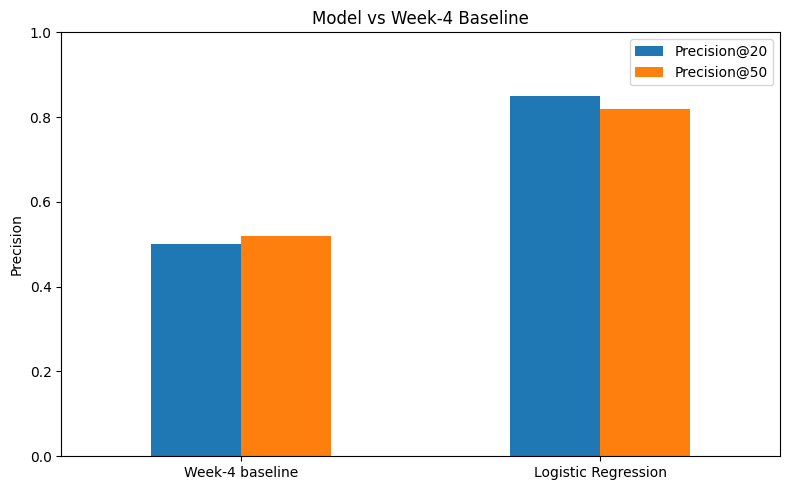

In [7]:
# ML-11 — Results table + chart

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Logistic Regression"
    ],
    "Precision@20": [
        0.50,
        0.85
    ],
    "Precision@50": [
        0.52,
        0.82
    ]
})

print("Test-set base rate: 0.6437")
print()
print(results.to_string(index=False))

# Chart
ax = results.set_index("Method")[
    ["Precision@20", "Precision@50"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Model vs Week-4 Baseline")
ax.set_ylabel("Precision")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Chart takeaway:** On the held-out-client split, the measured Logistic Regression precision was higher than the Week-4 baseline at both @20 and @50. The comparison is specific to this experiment and should not be interpreted as a guarantee of future performance.

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This study has several important limits.

- The experiment uses a March 2026 feature window and an April 2026 future-decline window. Results may differ under other periods or outcome definitions.
- The future-decline label is a declared experimental definition based on average daily GSC impressions; it is not a universal definition of content decay.
- The main evaluation uses eight held-out clients. The grouped split prevents client overlap, but the test clients are not identical to the training clients.
- The positive-label rate was 0.4664 in training and 0.6437 in the held-out test set, indicating a noticeable difference in outcome prevalence between the two groups.
- Search and Analytics data availability varies across clients and dates. Missing or unavailable data can affect the observations that enter the model.
- The model uses only five search-performance features and does not capture all relevant business, editorial, search-intent, or SERP context.
- The analysis measures ranking performance. It does not establish that changing or refreshing a page causes better search performance.
- The recommendations are therefore decision-support suggestions for human review, not automatic content actions or guaranteed outcomes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

The model output should be used as a review queue rather than an automatic action list.

### Priority 1 — Review high-risk, visible observations

Start with observations that have a high predicted probability of the future-decline outcome and meaningful March search exposure.

**Reason:** these observations combine a higher measured model score with enough observed search activity to make human review potentially useful.

**Human action:** inspect the page, current search context, search intent, recent changes, and business context before deciding whether a refresh is appropriate.

### Priority 2 — Inspect high-risk observations with weak CTR context

Where a high-risk observation also shows weak CTR relative to its observed position, review the title, snippet, search intent, and page/result alignment.

**Reason:** the model and the earlier baseline both identified CTR-related signals as useful directional evidence.

### Priority 3 — Monitor low-evidence high-risk observations

High-risk observations with limited current evidence should be reviewed more cautiously.

**Reason:** sparse or changing data can make the ranking less stable.

### Default action — Monitor

Lower-ranked observations should remain in monitoring rather than receiving an automatic change.

### Human-review rule

No recommendation should be treated as proof that a page needs a particular edit. The ranked score identifies observations to inspect first; the final content decision remains with a human reviewer.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The paper uses a small set of reproducible artifacts generated from the notebook:

- A model-vs-baseline precision chart.
- The model-vs-baseline metrics table.
- A validation note showing the client-grouped split and zero client overlap.
- The ranked action queue and metrics receipt generated by the ML-10 playbook notebook.

The queue CSV remains a generated working artifact and is not required to be committed to the public repository.

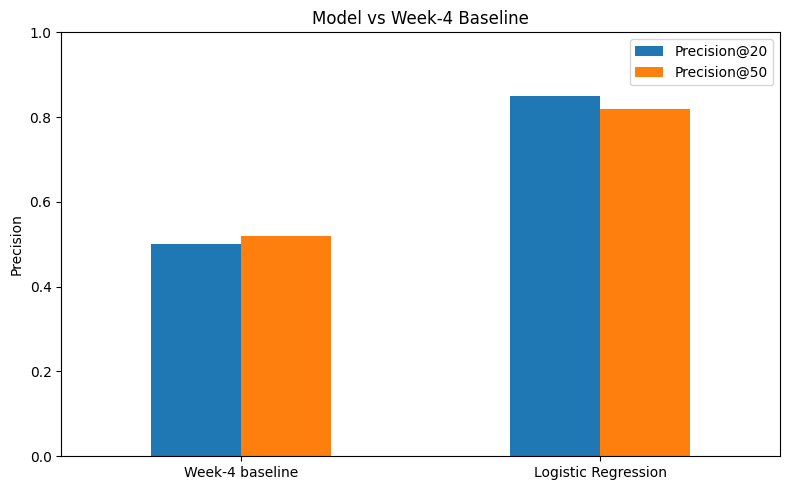

Saved figure: work/figures/model_vs_baseline_precision.png


In [8]:
# ML-11 — Save reusable paper figure

import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

figure_path = "work/figures/model_vs_baseline_precision.png"

ax = results.set_index("Method")[
    ["Precision@20", "Precision@50"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Model vs Week-4 Baseline")
ax.set_ylabel("Precision")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [Yes] Every section above is filled — markdown thinking AND the code that backs it
- [Yes] The notebook runs top to bottom with no errors (Runtime → Run all)
- [Yes] No client names, URLs, or private queries anywhere
- [Yes] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.